# Vectors, Matrices, and Linear Algebra with Real Data
_A hands-on notebook_Dr. Asif

This notebook explores real-world datasets and shows how to represent them using **vectors**, **matrices**, and basic **linear algebra operations**.

We will work through six scenarios:

1. House prices (tabular data)
2. Images as matrices (digit / medical images)
3. Movie recommendation (ratings matrix)
4. Text / NLP (document vectors)
5. Patient health records (medical data)
6. Small business sales (dot product & matrix–vector)

---


## 1. House Prices – Tabular Data

You have a dataset of houses. For each house you record:

- Size in square feet
- Number of bedrooms
- Age of the house in years
- Distance to city center in km
- Price in dollars (target)

![alt text](image.png)


In [1]:
# Common imports used throughout the notebook
import numpy as np

In [ ]:
# 1. House Prices – Python representation

# Each row: [size, bedrooms, age, distance]
X = np.array([
    [1400, 3, 10, 5.0],
    [2000, 4, 5,  8.0],
    [850,  2, 20, 3.0],
])

# Target prices (in $1000s)
y = np.array([300, 450, 200])

# Example weights (size, bedrooms, age, distance)
w = np.array([0.15, 10.0, -1.0, -2.0])

y_hat = X @ w   # matrix-vector multiplication
print("X shape:", X.shape)
print("w shape:", w.shape)
print("Predicted prices (y_hat):", y_hat)

### Practice Problem 1 – House prices

1. Create a new house with: 1800 sqft, 3 bedrooms, 8 years old, 6 km away.  
   - Represent it as a NumPy vector.  
2. Add a new feature `has_garage` (0 or 1).  
   - Extend `X` and `w` accordingly.  
   - Check that `X.shape` and `w.shape` are compatible for `X @ w`.  
3. Print the prediction for your new house.

In [8]:
# TODO: Student space for house-price exercises
import numpy as np

new_house = np.array([1800,3,8,6])
print(new_house)

#add a new feature garage
new_house = np.append(new_house, 1)
print(new_house)

#assign weight to each feature
w = np.array([0.15,10.0,-1.0,-2.0,1])

print("new_house shape =", new_house.shape)
print("w cshape =", w.shape)

#calculate prediction
price_pred = new_house @ w
print(price_pred)

[1800    3    8    6]
[1800    3    8    6    1]
new_house.shape = (5,)
w.shape = (5,)
281.0


## 2. Images as Matrices (Digit / Medical Images)

Consider grayscale images of size 28×28 pixels.

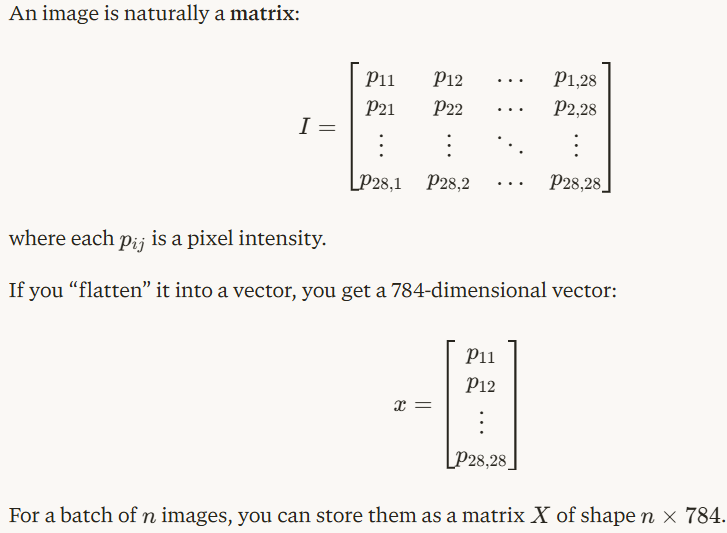

In [ ]:
# 2. Images – Python representation

# One image as a 28x28 matrix (random pixels here as a stand-in)
I = np.random.randint(0, 256, size=(28, 28))
print("Single image shape:", I.shape)

# Flatten to a vector of length 784
x = I.reshape(-1)          # or I.flatten()
print("Flattened image shape:", x.shape)

# Suppose we have 5 images
images = np.random.randint(0, 256, size=(5, 28, 28))
print("Batch images shape:", images.shape)

# Flatten each image -> data matrix X (5 x 784)
X_img = images.reshape(5, -1)
print("Flattened batch shape:", X_img.shape)

### Practice Problem 2 – Images

1. Describe in words what each row of `X_img` represents.  
2. Verify in code that `X_img[0]` has length 784.  
3. Apply a brightness scaling factor of `0.5` to all pixel values of `images` and show that the shape does not change.

In [ ]:
# TODO: Student space for image exercises

# 1. Check the length of the first flattened image
# print(len(X_img[0]))

# 2. Scale brightness
# images_scaled = ...
# print("Scaled images shape:", images_scaled.shape)

## 3. Movie Recommendations – Ratings Matrix

Imagine a platform with 4 users and 5 movies. Ratings are from 1 to 5, or 0 if not rated.

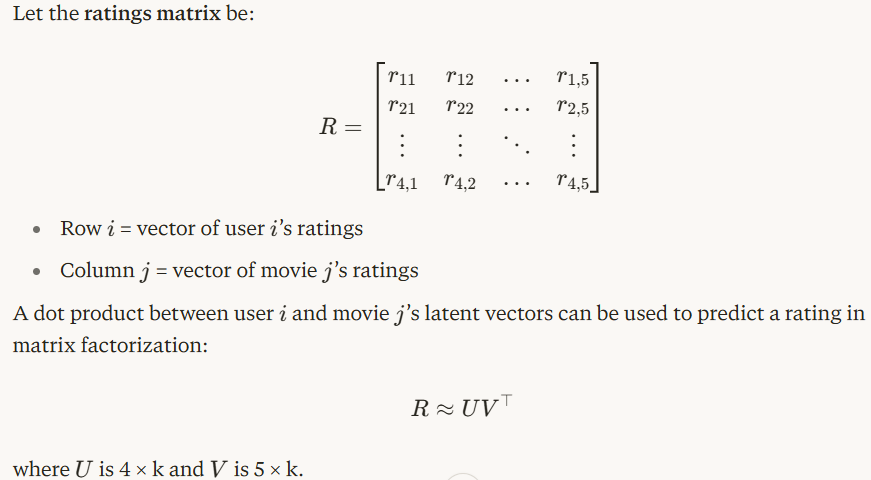

In [ ]:
# 3. Movie recommendations – Python representation

R = np.array([
    [5, 4, 0, 1, 0],
    [4, 0, 0, 1, 2],
    [0, 1, 5, 4, 0],
    [1, 0, 4, 0, 5],
])

print("Ratings matrix R:\n", R)
print("R shape:", R.shape)

# User 0's rating vector
user0 = R[0, :]   # shape (5,)
print("User 0 rating vector:", user0)

# Movie 2's ratings vector
movie2 = R[:, 2]  # shape (4,)
print("Movie 2 rating vector:", movie2)

### Practice Problem 3 – Movie recommendations

1. Interpret the first row of `R` in words.  
2. Interpret the third column of `R` in words.  
3. Suppose each movie has a 2D “genre embedding” vector and each user has a 2D “taste” vector.  
   - Sketch how a dot product between these vectors could estimate a rating.

In [ ]:
# TODO: Student space for movie exercises

# Example: you could create small U and V matrices and compute U @ V.T
# k = 2
# U = ...
# V = ...
# R_hat = U @ V.T
# print(R_hat)

## 4. Text / NLP – Document Vectors

We use a small vocabulary of 4 words:

- "good", "bad", "movie", "food"


For each document, define a **bag-of-words vector**:

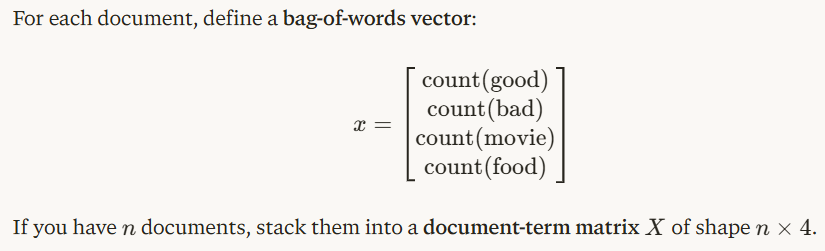

In [ ]:
# 4. Text / NLP – Python representation

# 3 documents represented as [good, bad, movie, food]
X_text = np.array([
    [1, 0, 1, 0],  # "good movie"
    [0, 2, 0, 1],  # "bad bad food"
    [1, 0, 0, 1],  # "good food"
])

print("Document-term matrix X_text:\n", X_text)
print("Shape:", X_text.shape)

### Practice Problem 4 – Text / NLP

1. Write the vector for a document containing: "bad movie bad".  
2. Append it as a new row to `X_text`.  
3. How would you conceptually use vector similarity (e.g., cosine similarity) to find documents that are similar?

In [ ]:
# TODO: Student space for text exercises

# 1. Create the vector for "bad movie bad"
# new_doc = ...

# 2. Append to X_text
# X_text_extended = ...
# print("Extended X_text:\n", X_text_extended)

## 5. Patient Health Records – Medical Data

We have these features:

- Age (years)  
- Systolic blood pressure (SBP)  
- Heart rate (HR)  
- Has diabetes (0 or 1)  

Target: probability of readmission.

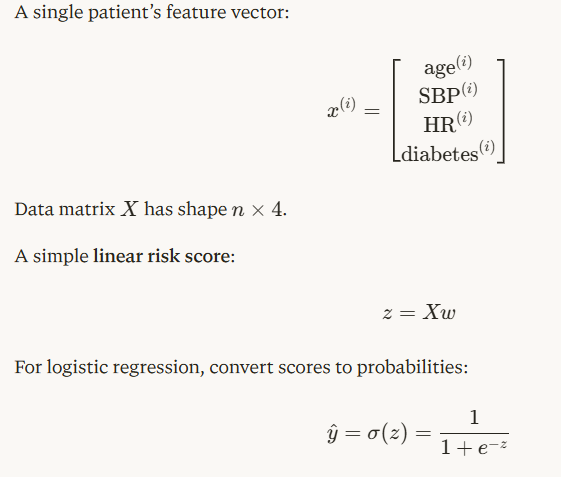

In [ ]:
# 5. Patient Health Records – Python representation

# Each row: [age, sbp, hr, diabetes]
X_med = np.array([
    [65, 140, 80, 1],
    [40, 120, 70, 0],
    [75, 160, 90, 1],
])

# Example weights
w_med = np.array([0.02, 0.01, 0.03, 0.5])

z = X_med @ w_med

def sigmoid(t):
    return 1 / (1 + np.exp(-t))

y_hat_med = sigmoid(z)

print("X_med shape:", X_med.shape)
print("w_med shape:", w_med.shape)
print("Risk scores (z):", z)
print("Probabilities (y_hat_med):", y_hat_med)

### Practice Problem 5 – Patient health records

1. In your own words, what is `X_med @ w_med` doing to each patient?  
2. Add a new feature `"smoker"` (0 or 1) to each row.  
   - Update `w_med` accordingly.  
   - Confirm that shapes still match.  
3. Experiment with changing one weight in `w_med` and observe how probabilities change.

In [ ]:
# TODO: Student space for medical data exercises

# 1. Add a "smoker" feature
# X_med_extended = ...
# w_med_extended = ...

# 2. Recompute z and y_hat and compare
# z_ext = ...
# y_hat_ext = ...
# print(y_hat_ext)

## 6. Small Business Sales – Dot Product & Matrix–Vector

A small shop sells three products:

- Apples, Bananas, Cherries

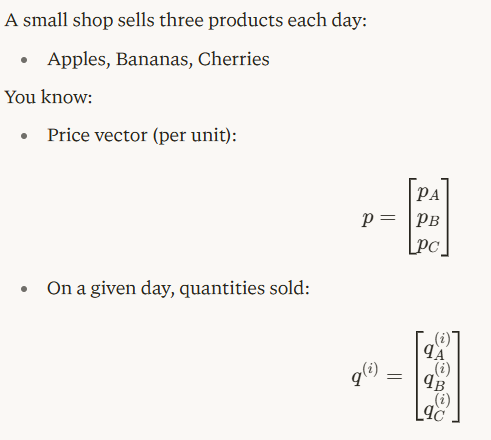
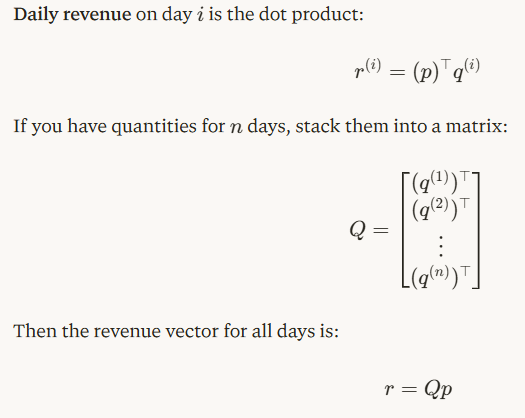

In [ ]:
# 6. Small Business Sales – Python representation

# Prices: [apple, banana, cherry]
p = np.array([3.0, 2.0, 5.0])

# Quantities for 4 days
Q = np.array([
    [10, 5, 2],   # day 1
    [0,  8, 1],   # day 2
    [3,  3, 3],   # day 3
    [7,  0, 4],   # day 4
])

# Daily revenues
r = Q @ p   # shape (4,)
print("Q shape:", Q.shape)
print("p shape:", p.shape)
print("Daily revenues:", r)

### Practice Problem 6 – Small business sales

1. Compute the revenue for the first day by hand using the dot product formula and compare with `r[0]`.  
2. Add a fourth product `"Dates"` with some price and daily quantities.  
   - Update `p` and `Q`.  
   - Confirm that shapes still allow `Q @ p`.  
3. Experiment with price changes and see how the revenue vector changes.

In [ ]:
# TODO: Student space for small-business exercises

# 1. Manually compute r_day1 using dot product
# r_day1_manual = ...
# print("Manual day 1 revenue:", r_day1_manual)

# 2. Add "Dates" as a fourth product
# p_extended = ...
# Q_extended = ...
# r_extended = ...
# print("Extended daily revenues:", r_extended)

## Reflection

Pick one scenario (houses, images, movies, text, patients, or business):

- Describe in 2–3 sentences how a **single example** is a vector.  
- Describe how the **collection of examples** forms a matrix.  
- Give one linear algebra operation (dot product, matrix–vector, reshape, etc.) that appears in that scenario and explain it in plain language.